<a href="https://colab.research.google.com/github/priyankconnect/MyProjects/blob/main/Indian_Saree_Image_Analysis_with_ArcFace_and_GCN_v1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Table of Contents

1.  **Dataset Overview & Initial Inspection**
    *   [Check First Five Values in a Folder](#scrollTo=MmtLKMCTb2bu)
    *   [Count Images in Each Cluster](#scrollTo=uxuWbDdXb2b3)

2.  **Data Deduplication**
    *   [Introduction to Deduplication](#scrollTo=krpI5GEYb2b5)
    *   [Identify Duplicate Groups](#scrollTo=vU3alzlfb2b8)
    *   [Inspect Sample Duplicate Groups](#scrollTo=dBnco9K1b2b9)
    *   [Visualize Duplicate Images](#scrollTo=10ngwPv6b2b-)
    *   [Remove Duplicates & Create Clean Dataset](#scrollTo=9roqNwasb2b_)
    *   [Verify Clean Dataset Image Count](#scrollTo=0Sb1_7gQb2cB)

3.  **Feature Extraction with ResNet-50**
    *   [Load Pretrained ResNet-50 Model](#scrollTo=-MVF_e9Lb2cC)
    *   [Define Image Transformations](#scrollTo=70l-XvxXb2cD)
    *   [Extract Embeddings for All Images](#scrollTo=Pt8VztqRb2cD)
    *   [Save Embeddings, Labels, and Paths](#scrollTo=JTTxytH6b2cE)

4.  **Layout-based Clustering**
    *   [Load Embeddings for Clustering](#scrollTo=KEefvpupb2cF)
    *   [KMeans Clustering per Saree Cluster](#scrollTo=lOnTqW_Hb2cF)
    *   [Combine and Save All Layout Labels](#scrollTo=ipQJWk9mb2cG)
    *   [Inspect Layouts for a Specific Cluster (e.g., Baluchari)](#scrollTo=9f0-9Yuob2cH)
    *   [Visualize Layout Clusters with Sample Images](#scrollTo=LJVUGNSsb2cH)
    *   [Perform 10-Layout Clustering](#scrollTo=zSFXHHgrb2cJ)
    *   [Create Layout-Structured Dataset](#scrollTo=fgIONpMLb2cK)

5.  **Dataset Splitting**
    *   [Define Train/Val/Test Ratios](#scrollTo=30ocwBcab2cK)
    *   [Stratified Dataset Split (Random)](#scrollTo=wpKlHAkxb2cL)
    *   [Verify Stratified Split Counts](#scrollTo=usAHlrYMb2cO)
    *   [Check Layout Count in Structured Dataset](#scrollTo=icT4oNTAb2cP)
    *   [Cross-Domain Dataset Split (by Layout)](#scrollTo=oOddjs5sb2cP)
    *   [Verify Cross-Domain Split (Test Examples)](#scrollTo=Gc0rdJ-1b2cR)

6.  **ArcFace Model Training & Evaluation (Cross-Domain)**
    *   [Setup PyTorch Environment and DataLoaders](#scrollTo=UgkSiLy6b2cT)
    *   [Define ArcFace Layer and ResNet18ArcFace Model](#scrollTo=zR2YklF8b2cU)
    *   [Initialize Model, Loss, and Optimizer](#scrollTo=lCapsvRfb2cV)
    *   [Train ArcFace Model](#scrollTo=ahtz15sFb2cW)
    *   [Evaluate ArcFace Model on Test Set](#scrollTo=MElMw0FLb2cX)

7.  **Graph Neural Network (GCN) for Classification**
    *   [Install PyTorch Geometric](#scrollTo=vD0WduTfb2cX)
    *   [Build Graph from Embeddings (k-NN)](#scrollTo=e4NJWZXrb2cY)
    *   [GCN Model Architecture](#scrollTo=xkaDPLJkb2cZ)
    *   [Initialize GCN Model, Loss, and Optimizer](#scrollTo=0yqAn_Vrb2ca)
    *   [Create Train/Validation/Test Masks](#scrollTo=QK-3j_Lib2ca)
    *   [Train GCN Model](#scrollTo=sS3Q3Qyvb2cb)
    *   [Evaluate GCN Model on Test Set](#scrollTo=MEdYy7Vtb2cd)

8.  **Analysis and Visualization**
    *   [t-SNE Visualization of Saree Embeddings](#scrollTo=21MEcazFb2ce)
    *   [Save Predictions for Analysis](#scrollTo=uuCA_SmFb2cf)
    *   [t-SNE with Misclassified Samples (Overall)](#scrollTo=P2TdMfFHb2ci)
    *   [t-SNE with Misclassified Samples (Test Set)](#scrollTo=NfF-1Pldb2ci)
    *   [Compute Cluster Centroids and Similarity Matrix](#scrollTo=aSNkiJoUb2cj)
    *   [Visualize Saree Cluster Similarity Map](#scrollTo=AuIyPiglb2ck)
    *   [Identify Most Similar Saree Pairs](#scrollTo=oD5XJjRVb2cm)
    *   [Visualize Saree Tradition Similarity Network](#scrollTo=qaLwYcpFb2co)
    *   [Geographic Map of Saree Traditions](#scrollTo=pmQ_2Cu6b2cs)
    *   [Dendrogram of Saree Traditions (Hierarchical Clustering)](#scrollTo=Rn1pU0MPb2ct)


In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
# Run only for the first time
#!ls /content/drive/MyDrive
!unzip -q /content/drive/MyDrive/Dataset.zip -d /content/

replace /content/Dataset/Baluchari/ah5035940_m-2_19b55161.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

## See the first Five Values in a folder to check if it is not appended by test etc.

In [41]:
!ls /content/Dataset

Baluchari	Ilkal	       Kota	    Orissa_Ikat        Venkatgiri_Silk
Banaras		Kalamkari      Maheshwari   Paithani
Champa_Tussar	Kanchi_Cotton  Mangalgiri   Pochampally_Ikat
Dhakai_Jamdani	Kanjivaram     Mysore_Silk  Uppada
Gadwal		Kerala_Kasavu  Narayanpet   Venkatgiri_Cotton


## Count the Number of Images in Each Cluster and Total No of Images and Total Number of Clusters

In [42]:
import os

dst_root = "/content/Dataset/"

total_images = 0

print("=== Cluster Counts ===\n")

for cluster in sorted(os.listdir(dst_root)):
    cluster_path = os.path.join(dst_root, cluster)

    if not os.path.isdir(cluster_path):
        continue

    images = [f for f in os.listdir(cluster_path)
              if os.path.isfile(os.path.join(cluster_path, f))]

    count = len(images)
    total_images += count

    print(f"{cluster:25s} {count:5d}")

print("\n======================")
print(f"Total Images: {total_images}")

=== Cluster Counts ===

Baluchari                   265
Banaras                     261
Champa_Tussar               592
Dhakai_Jamdani              526
Gadwal                      454
Ilkal                       254
Kalamkari                   709
Kanchi_Cotton               705
Kanjivaram                  740
Kerala_Kasavu               331
Kota                        467
Maheshwari                  234
Mangalgiri                  228
Mysore_Silk                 889
Narayanpet                  223
Orissa_Ikat                 400
Paithani                    397
Pochampally_Ikat            580
Uppada                      902
Venkatgiri_Cotton           339
Venkatgiri_Silk             318

Total Images: 9814


## Remove Duplicates

## Deduplication
The deduplication process uses a hash-based exact duplicate detection method based on the MD5 cryptographic hash function. For each image file in the dataset, the program reads the file in binary mode and computes a unique MD5 hash value representing the exact byte content of that file. These hash values are stored in a dictionary where each hash key maps to the list of file paths that produce the same hash. If multiple files generate the same MD5 hash, it indicates that their binary contents are identical, meaning they are exact duplicates of the same image. The code then identifies such cases by selecting hash entries associated with more than one file path and reports them as duplicate groups. This method is efficient for large datasets and ensures reliable detection of bit-wise identical images, although it does not detect near-duplicates such as resized or slightly modified versions of the same image.

It is called “number of duplicate groups” because the code groups together all files that share the same MD5 hash.

In [43]:
import os
import hashlib
from collections import defaultdict

def get_md5(file_path):
    hash_md5 = hashlib.md5()
    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()

data_root = "/content/Dataset/" # change if needed

hash_dict = defaultdict(list)

for root, dirs, files in os.walk(data_root):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            path = os.path.join(root, file)
            file_hash = get_md5(path)
            hash_dict[file_hash].append(path)

duplicates = {h: paths for h, paths in hash_dict.items() if len(paths) > 1}

print("Number of duplicate groups:", len(duplicates))

Number of duplicate groups: 69


In [8]:
for h, paths in list(duplicates.items())[:5]:
    print("\nDuplicate group:")
    for p in paths:
        print(p)


Duplicate group:
/content/Dataset/Pochampally_Ikat/pochampally_82.jpg
/content/Dataset/Pochampally_Ikat/pochampally_360.jpg

Duplicate group:
/content/Dataset/Pochampally_Ikat/pochampally_143.jpg
/content/Dataset/Pochampally_Ikat/pochampally_469.jpg

Duplicate group:
/content/Dataset/Pochampally_Ikat/pochampally_346.jpg
/content/Dataset/Pochampally_Ikat/pochampally_86.jpg

Duplicate group:
/content/Dataset/Pochampally_Ikat/pochampally_434.jpg
/content/Dataset/Pochampally_Ikat/pochampally_180.jpg

Duplicate group:
/content/Dataset/Pochampally_Ikat/pochampally_460.jpg
/content/Dataset/Pochampally_Ikat/pochampally_92.jpg



Duplicate Group 1


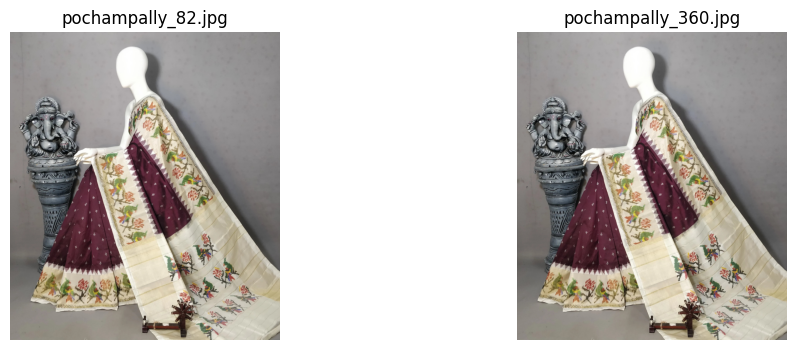


Duplicate Group 2


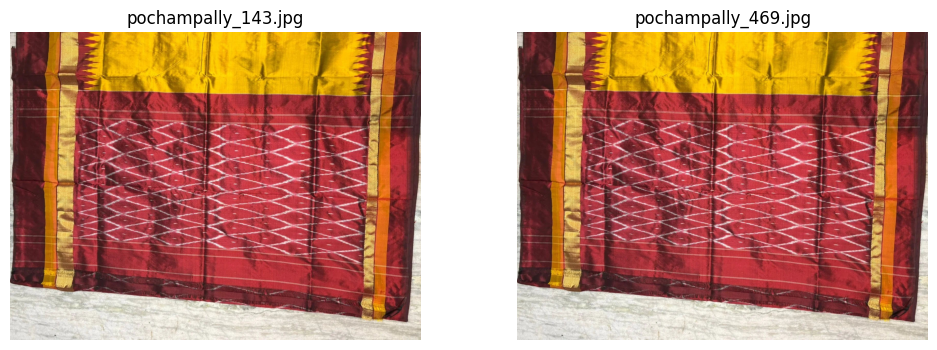


Duplicate Group 3


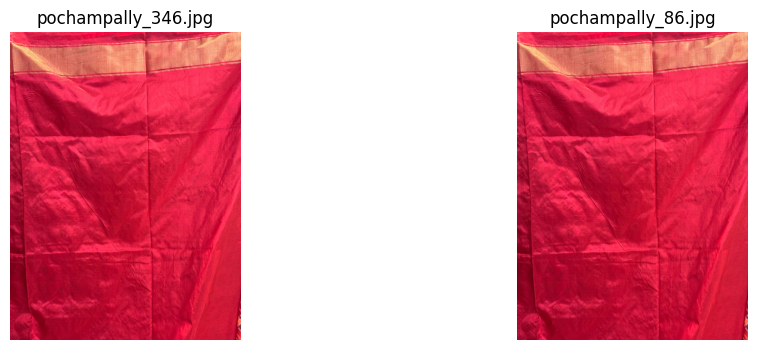


Duplicate Group 4


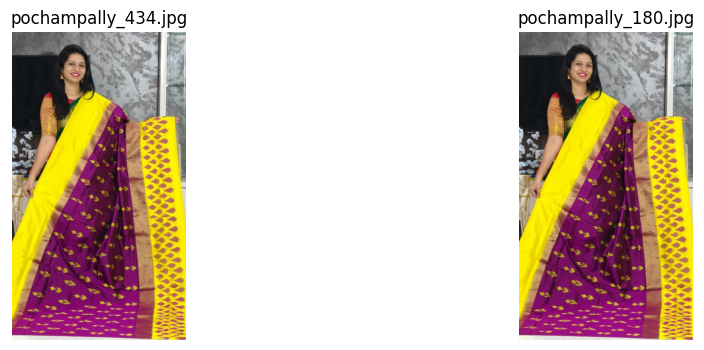


Duplicate Group 5


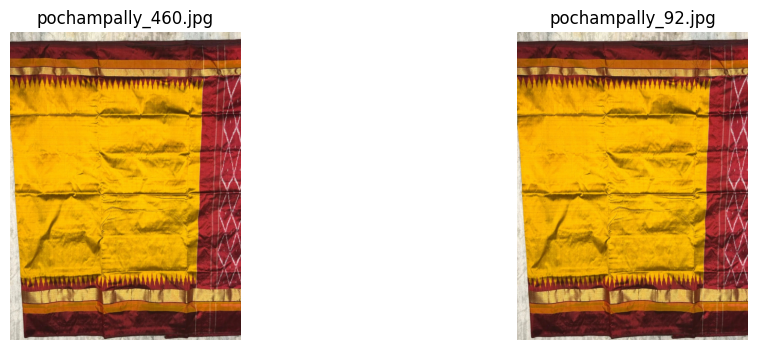

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

# number of duplicate groups you want to inspect
groups_to_show = 5

for i, (h, paths) in enumerate(duplicates.items()):

    if i >= groups_to_show:
        break

    print(f"\nDuplicate Group {i+1}")

    plt.figure(figsize=(12,4))

    for j, p in enumerate(paths):

        img = Image.open(p)

        plt.subplot(1, len(paths), j+1)
        plt.imshow(img)
        plt.title(os.path.basename(p))
        plt.axis("off")

    plt.show()

[Back to Table of Contents](#table_of_contents)

The code scans a saree image dataset and computes an MD5 hash for each image to detect duplicate files.

It keeps only the first occurrence of each unique image and ignores duplicates based on the hash.

The unique images are copied into a clean dataset folder organized by saree cluster.

This helps create a deduplicated training dataset, which is important for reliable deep-learning models in your saree-origin classification research.

In [10]:
import os
import hashlib
import shutil
from collections import defaultdict

def get_md5(file_path):
    hash_md5 = hashlib.md5()
    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()

src_root = "/content/Dataset/"
clean_root = "/content/data_saree2_master_clean"

os.makedirs(clean_root, exist_ok=True)

hash_seen = {}

for root, dirs, files in os.walk(src_root):
    for file in files:
        if file.lower().endswith((".jpg",".jpeg",".png")):
            path = os.path.join(root, file)
            file_hash = get_md5(path)

            # Extract cluster name
            cluster = root.split("/")[-1]
            dst_cluster_path = os.path.join(clean_root, cluster)
            os.makedirs(dst_cluster_path, exist_ok=True)

            if file_hash not in hash_seen:
                hash_seen[file_hash] = path
                shutil.copy2(path, os.path.join(dst_cluster_path, file))

In [11]:
total = 0
for cluster in os.listdir(clean_root):
    cluster_path = os.path.join(clean_root, cluster)
    count = len(os.listdir(cluster_path))
    print(cluster, count)
    total += count

print("Total images after cleaning:", total)

Kalamkari 709
Pochampally_Ikat 572
Kanjivaram 740
Ilkal 252
Mysore_Silk 889
Orissa_Ikat 377
Narayanpet 222
Mangalgiri 228
Kota 463
Maheshwari 232
Gadwal 453
Venkatgiri_Silk 318
Banaras 255
Champa_Tussar 592
Uppada 890
Kanchi_Cotton 693
Paithani 387
Dhakai_Jamdani 526
Venkatgiri_Cotton 338
Baluchari 259
Kerala_Kasavu 331
Total images after cleaning: 9726


It loads a pretrained ResNet-50 model trained on ImageNet and moves it to GPU/CPU for computation.

The final classification layer (fc) is removed and replaced with Identity, converting the network into a feature extractor.

The model is set to evaluation mode so it can generate image embeddings for downstream tasks (e.g., similarity, clustering, or GNN input).

In [12]:
import os
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.fc = nn.Identity()
model = model.to(device)
model.eval()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 142MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [13]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

It loops through all saree image folders (clusters) and processes each image.

Each image is passed through the ResNet-50 feature extractor to generate embeddings (feature vectors).

The code stores embeddings, cluster labels, and image paths for later tasks such as classification, similarity graphs, or GNN modeling.

In [14]:
embeddings = []
labels = []
image_paths = []

cluster_names = sorted(os.listdir(data_root))
cluster_to_idx = {name: i for i, name in enumerate(cluster_names)}

for cluster in cluster_names:
    cluster_path = os.path.join(data_root, cluster)

    if not os.path.isdir(cluster_path):
        continue

    for fname in tqdm(os.listdir(cluster_path), desc=cluster):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img_path = os.path.join(cluster_path, fname)

        try:
            img = Image.open(img_path).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)

            with torch.no_grad():
                feat = model(img)

            embeddings.append(feat.squeeze().cpu().numpy())
            labels.append(cluster_to_idx[cluster])
            image_paths.append(img_path)

        except Exception:
            print("Skipping:", img_path)

embeddings = np.array(embeddings)
labels = np.array(labels)
image_paths = np.array(image_paths)

print("Clean extraction complete.")
print("Shape:", embeddings.shape)

Venkatgiri_Silk: 100%|██████████| 318/318 [00:18<00:00, 16.83it/s]


Clean extraction complete.
Shape: (9814, 2048)


In [15]:
import os
import numpy as np

save_root = "/content/arcface_outputs"
os.makedirs(save_root, exist_ok=True)

np.save(os.path.join(save_root, "embeddings.npy"), embeddings)
np.save(os.path.join(save_root, "labels.npy"), labels)
np.save(os.path.join(save_root, "image_paths.npy"), image_paths)

print("Embeddings saved successfully in Colab working directory.")

Embeddings saved successfully in Colab working directory.


In [16]:
import numpy as np
import os
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

save_root = "/content/arcface_outputs"

embeddings = np.load(os.path.join(save_root, "embeddings.npy"))
labels = np.load(os.path.join(save_root, "labels.npy"))
image_paths = np.load(os.path.join(save_root, "image_paths.npy"))

print("Loaded:", embeddings.shape)

Loaded: (9814, 2048)


For each saree cluster, the code groups the corresponding image embeddings and standardizes them for stable clustering.

It applies KMeans clustering (10 clusters) to discover different layout/style patterns within the same saree cluster.

The resulting layout labels and indices are stored for later analysis of intra-cluster visual variation.

In [17]:
layout_results = {}

unique_clusters = np.unique(labels)

for cluster_id in unique_clusters:
    idx = np.where(labels == cluster_id)[0]

    cluster_embeddings = embeddings[idx]
    cluster_paths = image_paths[idx]

    # Standardize (important for clustering stability)
    scaler = StandardScaler()
    cluster_embeddings_scaled = scaler.fit_transform(cluster_embeddings)

    # KMeans clustering
    kmeans = KMeans(n_clusters=10, random_state=42)
    layout_labels = kmeans.fit_predict(cluster_embeddings_scaled)

    layout_results[cluster_id] = {
        "indices": idx,
        "layout_labels": layout_labels
    }

print("Layout clustering complete.")

Layout clustering complete.


It combines the layout cluster labels from all saree clusters into a single array aligned with the original image order.

Each image is assigned its corresponding layout/style label discovered by KMeans clustering.

The final layout labels are saved to a .npy file for later use in modeling or analysis.

In [18]:
all_layout_labels = np.zeros_like(labels)

for cluster_id in layout_results:
    idx = layout_results[cluster_id]["indices"]
    all_layout_labels[idx] = layout_results[cluster_id]["layout_labels"]

np.save(os.path.join(save_root, "layout_labels.npy"), all_layout_labels)

print("Saved layout labels.")

Saved layout labels.


It selects one saree cluster (cluster_id = 0) and retrieves the images belonging to it.

It accesses the layout cluster labels assigned by KMeans for those images.

It prints the first 10 images with their layout label and file path to inspect clustering results.

In [19]:
cluster_id = 0
idx = layout_results[cluster_id]["indices"]
layouts = layout_results[cluster_id]["layout_labels"]
paths = image_paths[idx]

for i in range(10):
    print("Layout:", layouts[i], "Path:", paths[i])

Layout: 7 Path: /content/Dataset/Baluchari/AH5337564_PB_c10a905f.jpg
Layout: 7 Path: /content/Dataset/Baluchari/baluchari_67.jpg
Layout: 9 Path: /content/Dataset/Baluchari/HB2528842_PB_35f971f5.jpg
Layout: 3 Path: /content/Dataset/Baluchari/baluchari_80.jpg
Layout: 7 Path: /content/Dataset/Baluchari/baluchari_94.jpg
Layout: 1 Path: /content/Dataset/Baluchari/HB2528851_M_e21ceb06.jpg
Layout: 7 Path: /content/Dataset/Baluchari/baluchari_115.jpg
Layout: 1 Path: /content/Dataset/Baluchari/AH5319408_AI_76311446.jpg
Layout: 7 Path: /content/Dataset/Baluchari/baluchari_22.jpg
Layout: 3 Path: /content/Dataset/Baluchari/baluchari_29.jpg


It analyzes the layout clusters within a specific saree cluster (cluster_id = 11) and counts how many images belong to each layout.

For each discovered layout, it randomly selects a few sample images.

The selected images are displayed using matplotlib to visually inspect layout patterns within the cluster.

Cluster ID: 11
Layout 0: 1 images
Layout 1: 24 images
Layout 2: 10 images
Layout 3: 23 images
Layout 4: 33 images
Layout 5: 34 images
Layout 6: 30 images
Layout 7: 36 images
Layout 8: 32 images
Layout 9: 11 images
Unique layout indices: [0 1 2 3 4 5 6 7 8 9]

Showing layout 0


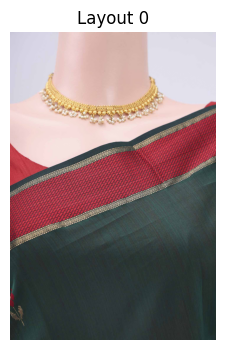


Showing layout 1


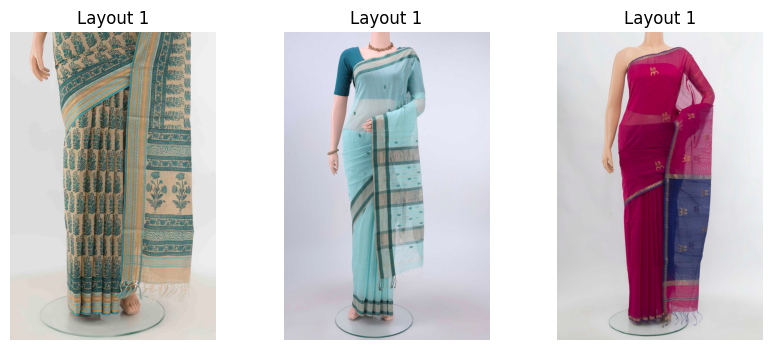


Showing layout 2


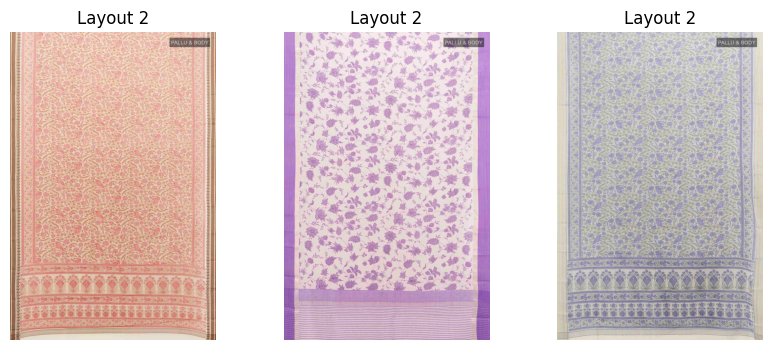


Showing layout 3


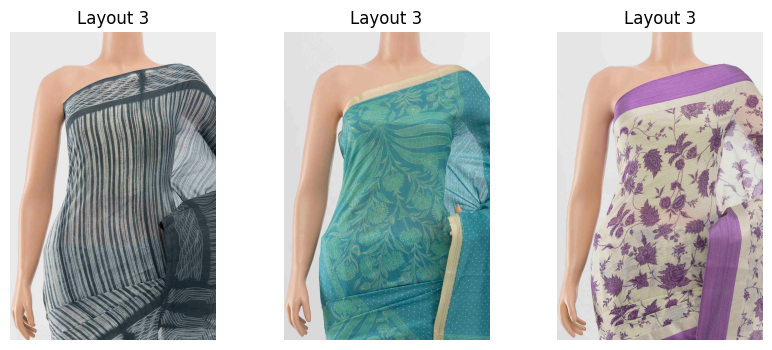


Showing layout 4


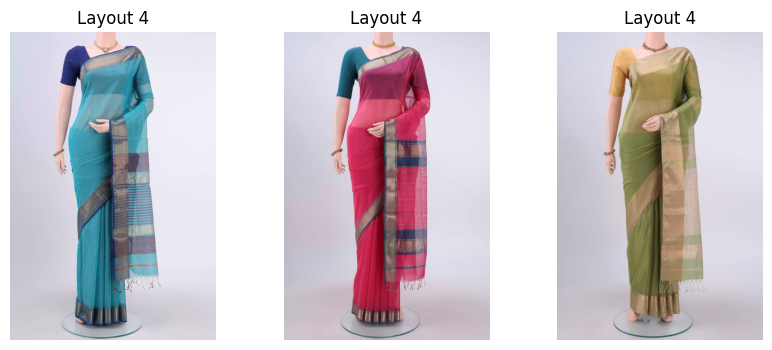


Showing layout 5


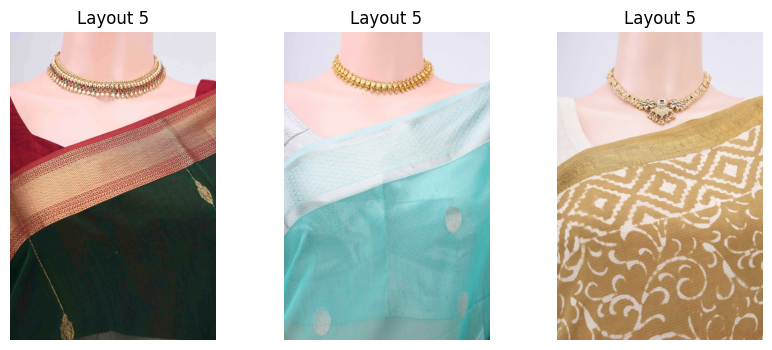


Showing layout 6


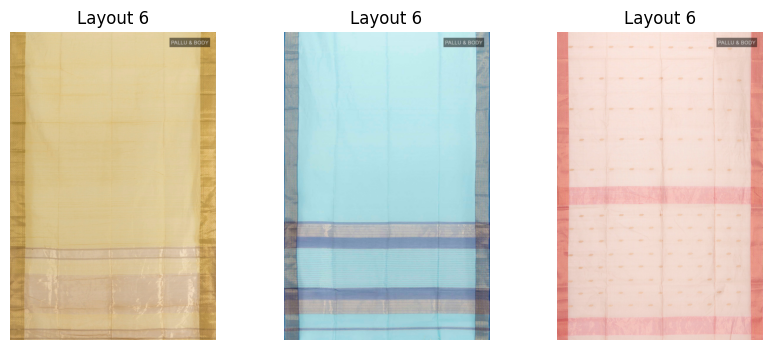


Showing layout 7


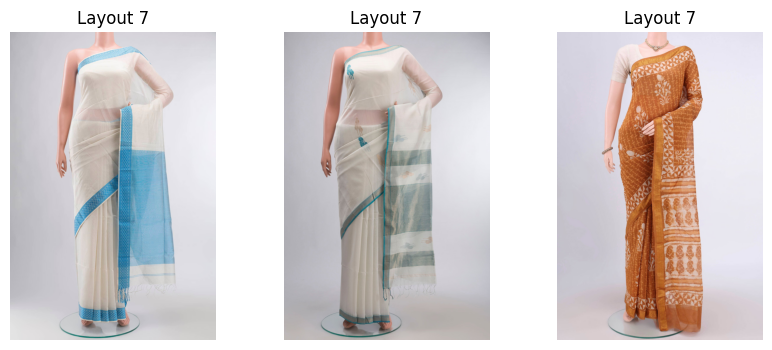


Showing layout 8


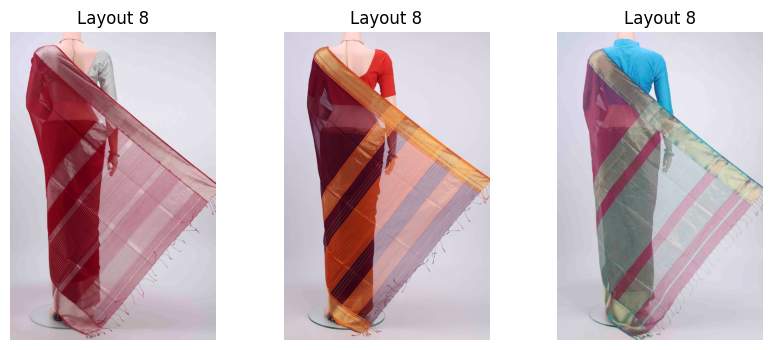


Showing layout 9


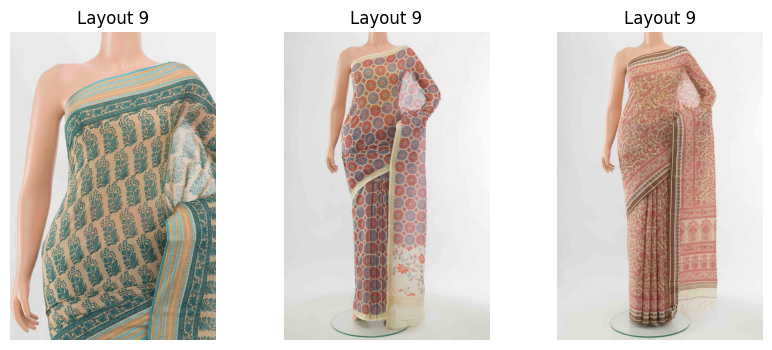

In [20]:
import matplotlib.pyplot as plt
from PIL import Image
import random
cluster_id = 11 # change if needed

idx = np.where(labels == cluster_id)[0]
layouts = all_layout_labels[idx]

unique, counts = np.unique(layouts, return_counts=True)

print("Cluster ID:", cluster_id)
for u, c in zip(unique, counts):
    print(f"Layout {u}: {c} images")

idx = np.where(labels == cluster_id)[0]
layouts = all_layout_labels[idx]

print("Unique layout indices:", np.unique(layouts))

idx = np.where(labels == cluster_id)[0]
layouts = all_layout_labels[idx]
paths = image_paths[idx]

unique_layouts = np.unique(layouts)

for layout in unique_layouts:
    print(f"\nShowing layout {layout}")

    layout_indices = np.where(layouts == layout)[0]
    selected = random.sample(list(layout_indices), min(3, len(layout_indices)))

    plt.figure(figsize=(10,4))

    for i, sel in enumerate(selected):
        img = Image.open(paths[sel])

        plt.subplot(1, len(selected), i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Layout {layout}")

    plt.show()

For each saree cluster, it selects the corresponding image embeddings.

It standardizes the embeddings and applies KMeans clustering (10 clusters) to identify different layout/style variations within the cluster.

The resulting layout labels are stored in layout10_labels for all images in the dataset.

In [21]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

layout10_labels = np.zeros_like(labels)

for cluster_id in np.unique(labels):

    idx = np.where(labels == cluster_id)[0]
    cluster_embeddings = embeddings[idx]

    scaler = StandardScaler()
    cluster_embeddings_scaled = scaler.fit_transform(cluster_embeddings)

    kmeans = KMeans(n_clusters=10, random_state=42)
    layout_labels = kmeans.fit_predict(cluster_embeddings_scaled)

    layout10_labels[idx] = layout_labels

print("10-layout clustering complete.")

10-layout clustering complete.


It reads images from the clean saree dataset and identifies their cluster and layout label.

It creates a new folder structure organized as cluster → layout (layout_0 … layout_9).

Each image is copied into its corresponding cluster-layout folder, creating a layout-structured dataset.

In [22]:
import os
import shutil

src_root = "/content/data_saree2_master_clean"
dst_root = "/content/data_saree2_layout10"

cluster_names = sorted(os.listdir(src_root))

for cluster_id, cluster_name in enumerate(cluster_names):

    cluster_indices = np.where(labels == cluster_id)[0]

    for idx in cluster_indices:

        layout_id = layout10_labels[idx]
        src_path = image_paths[idx]

        dst_folder = os.path.join(dst_root, cluster_name, f"layout_{layout_id}")
        os.makedirs(dst_folder, exist_ok=True)

        dst_path = os.path.join(dst_folder, os.path.basename(src_path))

        shutil.copy2(src_path, dst_path)

print("Layout-based dataset created.")

Layout-based dataset created.


In [23]:
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

It reads images from the cluster–layout organized dataset and shuffles them.

It splits the images into train (70%), validation (15%), and test (15%) sets while preserving layout distribution (stratified by layout).

The images are copied into a new folder structure: train/cluster, val/cluster, and test/cluster for model training.

In [24]:
import os
import random
import shutil

src_root = "/content/data_saree2_layout10"
dst_root = "/content/data_saree2_stratified"

splits = ["train", "val", "test"]

train_ratio = 0.7
val_ratio = 0.15

for cluster in os.listdir(src_root):
    cluster_path = os.path.join(src_root, cluster)

    if not os.path.isdir(cluster_path):
        continue

    for layout in os.listdir(cluster_path):
        layout_path = os.path.join(cluster_path, layout)

        images = [f for f in os.listdir(layout_path)
                  if f.lower().endswith((".jpg", ".jpeg", ".png"))]

        random.shuffle(images)

        n = len(images)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)

        train_imgs = images[:n_train]
        val_imgs = images[n_train:n_train+n_val]
        test_imgs = images[n_train+n_val:]

        for split_name, split_imgs in zip(
            splits, [train_imgs, val_imgs, test_imgs]
        ):
            for img in split_imgs:
                src_file = os.path.join(layout_path, img)

                dst_folder = os.path.join(dst_root, split_name, cluster)
                os.makedirs(dst_folder, exist_ok=True)

                dst_file = os.path.join(dst_folder, img)
                shutil.copy2(src_file, dst_file)

print("Stratified dataset created.")

Stratified dataset created.


In [25]:
for split in ["train", "val", "test"]:
    print("\n", split)
    split_path = os.path.join(dst_root, split)

    for cluster in os.listdir(split_path):
        count = len(os.listdir(os.path.join(split_path, cluster)))
        print(cluster, count)


 train
Kalamkari 490
Pochampally_Ikat 401
Kanjivaram 513
Ilkal 172
Mysore_Silk 619
Orissa_Ikat 276
Narayanpet 152
Mangalgiri 154
Kota 323
Maheshwari 160
Gadwal 313
Venkatgiri_Silk 218
Banaras 179
Champa_Tussar 409
Uppada 627
Kanchi_Cotton 487
Paithani 272
Dhakai_Jamdani 362
Venkatgiri_Cotton 233
Baluchari 180
Kerala_Kasavu 228

 val
Kalamkari 102
Pochampally_Ikat 83
Kanjivaram 106
Ilkal 33
Mysore_Silk 127
Orissa_Ikat 55
Narayanpet 30
Mangalgiri 30
Kota 65
Maheshwari 30
Gadwal 63
Venkatgiri_Silk 45
Banaras 34
Champa_Tussar 85
Uppada 130
Kanchi_Cotton 101
Paithani 55
Dhakai_Jamdani 74
Venkatgiri_Cotton 47
Baluchari 36
Kerala_Kasavu 44

 test
Kalamkari 117
Pochampally_Ikat 96
Kanjivaram 121
Ilkal 49
Mysore_Silk 143
Orissa_Ikat 69
Narayanpet 41
Mangalgiri 44
Kota 79
Maheshwari 44
Gadwal 78
Venkatgiri_Silk 55
Banaras 48
Champa_Tussar 98
Uppada 145
Kanchi_Cotton 117
Paithani 70
Dhakai_Jamdani 90
Venkatgiri_Cotton 59
Baluchari 49
Kerala_Kasavu 59


In [26]:
for cluster in os.listdir("/content/data_saree2_layout10"):
    layouts = os.listdir(os.path.join("/content/data_saree2_layout10", cluster))
    print(cluster, len(layouts))

Kalamkari 10
Pochampally_Ikat 10
Kanjivaram 10
Ilkal 10
Mysore_Silk 10
Orissa_Ikat 10
Narayanpet 10
Mangalgiri 10
Kota 10
Maheshwari 10
Gadwal 10
Venkatgiri_Silk 10
Banaras 10
Champa_Tussar 10
Uppada 10
Kanchi_Cotton 10
Paithani 10
Dhakai_Jamdani 10
Venkatgiri_Cotton 10
Baluchari 10
Kerala_Kasavu 10


It creates a cross-domain dataset split based on layout types rather than random image splits.

Layouts 0–7 are used for training (with 10% validation) while layouts 8–9 are kept completely unseen for testing.

This setup evaluates model generalization to new layout patterns (cross-domain testing).

In [27]:
import os
import shutil
import random

src_root = "/content/data_saree2_layout10"
dst_root = "/content/data_saree2_cross_domain"

train_layouts = [f"layout_{i}" for i in range(8)]   # 0–7
test_layouts = [f"layout_{i}" for i in range(8,10)] # 8–9

val_ratio = 0.1  # 10% of training layouts for validation

for cluster in os.listdir(src_root):
    cluster_path = os.path.join(src_root, cluster)

    for layout in os.listdir(cluster_path):
        layout_path = os.path.join(cluster_path, layout)

        images = [f for f in os.listdir(layout_path)
                  if f.lower().endswith((".jpg",".jpeg",".png"))]

        random.shuffle(images)

        if layout in train_layouts:
            n_val = int(len(images) * val_ratio)
            val_imgs = images[:n_val]
            train_imgs = images[n_val:]

            # Save train
            for img in train_imgs:
                src_file = os.path.join(layout_path, img)
                dst_folder = os.path.join(dst_root, "train", cluster)
                os.makedirs(dst_folder, exist_ok=True)
                shutil.copy2(src_file, os.path.join(dst_folder, img))

            # Save val
            for img in val_imgs:
                src_file = os.path.join(layout_path, img)
                dst_folder = os.path.join(dst_root, "val", cluster)
                os.makedirs(dst_folder, exist_ok=True)
                shutil.copy2(src_file, os.path.join(dst_folder, img))

        elif layout in test_layouts:
            for img in images:
                src_file = os.path.join(layout_path, img)
                dst_folder = os.path.join(dst_root, "test", cluster)
                os.makedirs(dst_folder, exist_ok=True)
                shutil.copy2(src_file, os.path.join(dst_folder, img))

print("Cross-domain dataset created.")

Cross-domain dataset created.


In [28]:
!ls "/content/data_saree2_cross_domain/test/Baluchari"| head -5

HB2484000_PB_df6eb410.jpg
HB2484015_PB_72a85867.jpg
HB2528835_PB_4316a1ab.jpg
HB2528842_PB_35f971f5.jpg
HB2528850_PB_c17ada45.jpg


It sets up the PyTorch environment, defines image preprocessing/augmentation, and selects GPU or CPU for training.

It loads the cross-domain saree dataset (train, validation, test) using ImageFolder.

It creates DataLoaders to efficiently feed batches of images to the model during training and evaluation.

In [29]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2,0.1,0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

eval_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = datasets.ImageFolder("/content/data_saree2_cross_domain/train/", transform=train_tf)
val_ds   = datasets.ImageFolder("/content/data_saree2_cross_domain/val/",   transform=eval_tf)
test_ds  = datasets.ImageFolder("/content/data_saree2_cross_domain/test/",  transform=eval_tf)

num_classes = len(train_ds.classes)
print("Classes:", num_classes, train_ds.classes)

train_ld = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_ld   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_ld  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

Device: cuda
Classes: 21 ['Baluchari', 'Banaras', 'Champa_Tussar', 'Dhakai_Jamdani', 'Gadwal', 'Ilkal', 'Kalamkari', 'Kanchi_Cotton', 'Kanjivaram', 'Kerala_Kasavu', 'Kota', 'Maheshwari', 'Mangalgiri', 'Mysore_Silk', 'Narayanpet', 'Orissa_Ikat', 'Paithani', 'Pochampally_Ikat', 'Uppada', 'Venkatgiri_Cotton', 'Venkatgiri_Silk']


It implements the ArcFace layer (ArcMarginProduct), which adds an angular margin to improve class separation in feature space.

It builds a ResNet-18 based model that outputs 512-dim embeddings instead of direct classification.

The embeddings are passed through the ArcFace layer to produce margin-based logits for improved classification performance.

In [30]:
import math

class ArcMarginProduct(nn.Module):
    """
    ArcFace: cos(theta + m) scaled by s
    """
    def __init__(self, in_features, out_features, s=30.0, m=0.30, easy_margin=False):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m
        self.easy_margin = easy_margin

        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, x, labels):
        # Normalize features and weights
        x = F.normalize(x, dim=1)
        W = F.normalize(self.weight, dim=1)

        # cosine: [B, C]
        cosine = F.linear(x, W).clamp(-1.0, 1.0)
        sine = torch.sqrt((1.0 - cosine**2).clamp(0, 1))

        # cos(theta+m)
        phi = cosine * self.cos_m - sine * self.sin_m

        if self.easy_margin:
            phi = torch.where(cosine > 0, phi, cosine)
        else:
            phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)

        logits = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        logits *= self.s
        return logits


class ResNet18ArcFace(nn.Module):
    def __init__(self, num_classes, s=30.0, m=0.30):
        super().__init__()
        self.backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        in_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()  # outputs 512-d embedding
        self.arc = ArcMarginProduct(in_dim, num_classes, s=s, m=m)

    def forward(self, x, labels=None):
        feat = self.backbone(x)  # [B, 512]
        if labels is None:
            # for inference we return plain cosine logits using arc weights (no margin)
            # (equivalent to cosine classifier)
            W = F.normalize(self.arc.weight, dim=1)
            feat_n = F.normalize(feat, dim=1)
            logits = F.linear(feat_n, W) * self.arc.s
            return logits, feat
        logits = self.arc(feat, labels)
        return logits, feat

It initializes the ResNet18 + ArcFace model and freezes most backbone layers to use pretrained features.

Only the last ResNet block (layer4) and the ArcFace classification head are made trainable for fine-tuning.

It defines the loss function (CrossEntropy) and optimizer (AdamW) for training the model.

In [31]:
model = ResNet18ArcFace(num_classes=num_classes, s=30.0, m=0.30).to(device)

# Freeze all backbone params first
for p in model.backbone.parameters():
    p.requires_grad = False

# Unfreeze last block (layer4) for mild fine-tuning
for p in model.backbone.layer4.parameters():
    p.requires_grad = True

# Arc head always trainable
for p in model.arc.parameters():
    p.requires_grad = True

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=2e-4,
    weight_decay=1e-4
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 196MB/s]


It defines an evaluation function to measure model accuracy on validation/test data.

It trains the ResNet18 + ArcFace model for multiple epochs, computing loss and updating weights using backpropagation.

The model monitors validation accuracy and saves the best-performing model during training.

In [32]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits, _ = model(x, labels=None)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(y.numpy())
    acc = (np.array(all_preds) == np.array(all_true)).mean()
    return acc, np.array(all_true), np.array(all_preds)

def train_arcface(model, epochs=15, save_path="best_arcface.pth"):
    best_val = 0.0

    for ep in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        n = 0

        progress_bar = tqdm(train_ld, desc=f"Epoch {ep}/{epochs}")

        for x, y in progress_bar:
            x, y = x.to(device), y.to(device)

            logits, _ = model(x, labels=y)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * y.size(0)
            n += y.size(0)

            progress_bar.set_postfix(loss=loss.item())

        train_loss = running_loss / n
        val_acc, _, _ = evaluate(model, val_ld)

        print(f"Epoch {ep:02d}/{epochs} | train_loss {train_loss:.4f} | val_acc {val_acc:.4f}")

        if val_acc > best_val:
            best_val = val_acc
            torch.save(model.state_dict(), save_path)

    print("Best val_acc:", best_val)

train_arcface(model, epochs=15, save_path="best_arcface.pth")

Epoch 1/15: 100%|██████████| 228/228 [04:21<00:00,  1.15s/it, loss=3.91]


Epoch 01/15 | train_loss 5.4974 | val_acc 0.8814


Epoch 2/15: 100%|██████████| 228/228 [04:01<00:00,  1.06s/it, loss=1.6]


Epoch 02/15 | train_loss 2.3785 | val_acc 0.9117


Epoch 3/15: 100%|██████████| 228/228 [03:58<00:00,  1.05s/it, loss=0.853]


...

Epoch 13/15 | train_loss 0.2936 | val_acc 0.9241


Epoch 14/15: 100%|██████████| 228/228 [03:56<00:00,  1.04s/it, loss=0.0445]


Epoch 14/15 | train_loss 0.2612 | val_acc 0.9366


Epoch 15/15: 100%|██████████| 228/228 [04:01<00:00,  1.06s/it, loss=0.727]


Epoch 15/15 | train_loss 0.2894 | val_acc 0.9393
Best val_acc: 0.9393103448275862


In [33]:
model.load_state_dict(torch.load("best_arcface.pth", map_location=device))
test_acc, y_true, y_pred = evaluate(model, test_ld)
print("Test accuracy:", round(test_acc, 4))
print(classification_report(y_true, y_pred, target_names=train_ds.classes))

Test accuracy: 0.6482
                   precision    recall  f1-score   support

        Baluchari       0.26      0.33      0.29        18
          Banaras       0.32      0.68      0.43        31
    Champa_Tussar       0.88      0.81      0.84        93
   Dhakai_Jamdani       0.96      0.97      0.97       115
           Gadwal       0.08      0.05      0.06        98
            Ilkal       0.88      0.90      0.89        63
        Kalamkari       0.80      0.80      0.80        95
    Kanchi_Cotton       0.78      0.77      0.77       118
       Kanjivaram       0.92      1.00      0.96       109
    Kerala_Kasavu       0.80      0.96      0.87        50
             Kota       0.47      0.28      0.35        99
       Maheshwari       0.34      0.88      0.49        43
       Mangalgiri       0.89      0.91      0.90        35
      Mysore_Silk       0.84      1.00      0.91       268
       Narayanpet       0.00      0.00      0.00        25
      Orissa_Ikat       0.30     

In [36]:
! pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.0 MB/s eta 0:00:00


1️⃣ Loads saree image embeddings and labels, converts them into PyTorch tensors so they can be used as node features and node labels.

2️⃣ Uses k-Nearest Neighbors (cosine similarity) to find the 10 most similar saree embeddings and creates edges between similar images, making the graph undirected.

3️⃣ Builds a PyTorch Geometric graph object (Data) where x = node features (embeddings), edge_index = connections between similar sarees, and y = craft cluster labels.

In [44]:
import torch
import numpy as np
from sklearn.neighbors import NearestNeighbors
from torch_geometric.data import Data

# Load embeddings and labels
embeddings = np.load("/content/arcface_outputs/embeddings.npy")
labels = np.load("/content/arcface_outputs/labels.npy")

# Convert to tensors
X = torch.tensor(embeddings, dtype=torch.float)
y = torch.tensor(labels, dtype=torch.long)

# Build k-NN graph using cosine similarity
k = 10
nbrs = NearestNeighbors(n_neighbors=k+1, metric='cosine').fit(embeddings)
distances, indices = nbrs.kneighbors(embeddings)

# Build edge list
edges = []

for i in range(len(indices)):
    for j in indices[i][1:]:  # skip self-edge
        edges.append([i, j])
        edges.append([j, i])  # make graph undirected

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# Create PyTorch Geometric graph object
data = Data(
    x=X,              # node features
    edge_index=edge_index,
    y=y               # labels
)

print(data)

Data(x=[9814, 2048], edge_index=[2, 196280], y=[9814])


Explaination of the Output  below:

1️⃣ x=[9814, 2048] → The graph has 9,814 nodes (saree images), each represented by a 2048-dimensional embedding feature vector from your CNN/ArcFace model.

2️⃣ edge_index=[2, 196280] → The graph contains 196,280 edges, stored as pairs of connected node indices (source → target) defining similarity relationships between sarees.

3️⃣ y=[9814] → Each node has a label indicating its saree craft cluster, used for training or evaluating the graph neural network.

1️⃣ self.conv1 = GCNConv(in_dim, hidden_dim) defines the first graph convolution layer, which transforms each node’s input feature vector (e.g., 2048-dim embedding) into a hidden representation while aggregating information from its neighbors.

2️⃣ This layer performs feature aggregation from connected nodes in the graph, allowing each saree embedding to incorporate information from visually similar sarees.

3️⃣ The output becomes a new learned representation for each node, which is then passed to the next layer for classification.

In [45]:
from torch_geometric.nn import GCNConv
import torch.nn.functional as F

class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)

        return x

1️⃣ num_features gets the feature size of each node (2048 from the embeddings), and num_classes counts how many saree clusters/classes exist in the dataset.

2️⃣ model = GCN(num_features, 256, num_classes) creates the GCN model, with a hidden layer of 256 units, and moves the model and graph data to the GPU/CPU device.

3️⃣ optimizer (Adam) updates model weights during training, while CrossEntropyLoss measures the classification error between predicted saree clusters and true labels.

In [46]:
num_features = data.x.shape[1]
num_classes = len(np.unique(labels))

model = GCN(num_features, 256, num_classes).to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

1️⃣ torch.randperm(num_nodes) randomly shuffles all node indices (saree images) to avoid bias in dataset splitting.

2️⃣ The dataset is split into 70% training, 15% validation, and 15% test nodes using the shuffled indices.

3️⃣ train_mask, val_mask, and test_mask store the indices of nodes used for training, model tuning, and final evaluation respectively.

In [47]:
num_nodes = data.num_nodes
perm = torch.randperm(num_nodes)

train_size = int(0.7 * num_nodes)
val_size = int(0.15 * num_nodes)

train_mask = perm[:train_size]
val_mask = perm[train_size:train_size+val_size]
test_mask = perm[train_size+val_size:]

Explanation of why it was not done cross domainwise and done random ( above): 1️⃣ Layout (domain/source) matters less here because GCN learns from the similarity graph, not directly from the raw image layout or source distribution.

2️⃣ Each node aggregates information from its neighboring nodes in embedding space, so learning depends on graph structure, not where the image came from.

3️⃣ If visually similar sarees connect in the graph, the model can propagate label information across neighbors, regardless of dataset layout.

1️⃣ For each epoch, the model performs a forward pass, computes loss on the training nodes (train_mask), and updates the model weights using backpropagation and the optimizer.

2️⃣ out = model(data) produces predicted class scores for every node (saree image) in the graph.

3️⃣ Every 10 epochs, the model switches to evaluation mode and computes training and validation accuracy by comparing predicted labels with true labels.

In [48]:
for epoch in range(1, 101):

    model.train()
    optimizer.zero_grad()

    out = model(data)
    loss = criterion(out[train_mask], data.y[train_mask])

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        model.eval()
        pred = out.argmax(dim=1)

        train_acc = (pred[train_mask] == data.y[train_mask]).float().mean()
        val_acc = (pred[val_mask] == data.y[val_mask]).float().mean()

        print(f"Epoch {epoch} | Loss {loss:.4f} | Train Acc {train_acc:.4f} | Val Acc {val_acc:.4f}")

Epoch 10 | Loss 20.6481 | Train Acc 0.0400 | Val Acc 0.0408
Epoch 20 | Loss 2.8076 | Train Acc 0.1689 | Val Acc 0.1739
Epoch 30 | Loss 2.0979 | Train Acc 0.3741 | Val Acc 0.4110
Epoch 40 | Loss 1.4427 | Train Acc 0.5704 | Val Acc 0.5788
Epoch 50 | Loss 1.0957 | Train Acc 0.6657 | Val Acc 0.6692
Epoch 60 | Loss 0.8576 | Train Acc 0.7375 | Val Acc 0.7317
Epoch 70 | Loss 0.7398 | Train Acc 0.7697 | Val Acc 0.7704
Epoch 80 | Loss 0.6729 | Train Acc 0.7888 | Val Acc 0.7826
Epoch 90 | Loss 0.6260 | Train Acc 0.8004 | Val Acc 0.7942
Epoch 100 | Loss 0.5896 | Train Acc 0.8103 | Val Acc 0.8037


Above: Why Training took so little time. 1️⃣ The graph is relatively small (≈9,814 nodes and 196k edges), so GCN message passing is computationally light.

2️⃣ You are not training a CNN, only a 2-layer GCN on already computed embeddings, which is much faster.

3️⃣ The entire graph is processed in one forward pass (full-batch training) instead of iterating through thousands of images.

1️⃣ model.eval() sets the model to evaluation mode, ensuring it behaves correctly during testing.

2️⃣ out = model(data) generates predictions for all nodes, and argmax(dim=1) selects the predicted class (saree cluster) for each node.

3️⃣ The code compares predictions with true labels of the test nodes (test_mask) and calculates the test accuracy, which is printed.

In [49]:
model.eval()

out = model(data)
pred = out.argmax(dim=1)

test_acc = (pred[test_mask] == data.y[test_mask]).float().mean()

print("Test Accuracy:", test_acc.item())

Test Accuracy: 0.7942973375320435


1️⃣ The code loads saree image embeddings and labels, then uses t-SNE to reduce the 2048-dimensional embeddings to 2 dimensions for visualization.

2️⃣ Each point in X_tsne represents one saree image positioned based on similarity in embedding space.

3️⃣ The scatter plot colors points by saree cluster label, allowing you to visually see whether different saree traditions form separate clusters.

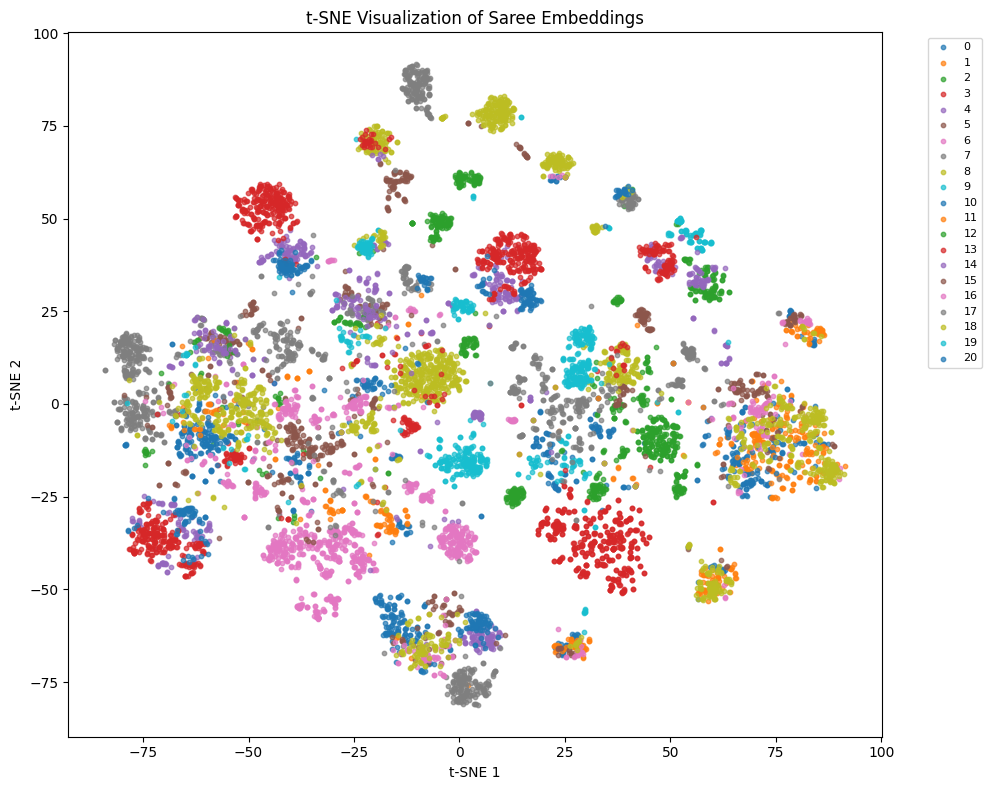

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Load embeddings and labels
embeddings = np.load("/content/arcface_outputs/embeddings.npy")
labels = np.load("/content/arcface_outputs/labels.npy")

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
X_tsne = tsne.fit_transform(embeddings)

# Plot clusters
plt.figure(figsize=(10,8))
num_classes = len(np.unique(labels))

for c in range(num_classes):
    idx = labels == c
    plt.scatter(X_tsne[idx,0], X_tsne[idx,1], s=10, label=str(c), alpha=0.7)

plt.title("t-SNE Visualization of Saree Embeddings")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [51]:
model.eval()

out = model(data)
pred = out.argmax(dim=1)

preds = pred.cpu().numpy()
labels = data.y.cpu().numpy()

np.save("/content/predictions.npy", preds)
np.save("/content/labels.npy", labels)

print("Predictions saved.")

Predictions saved.


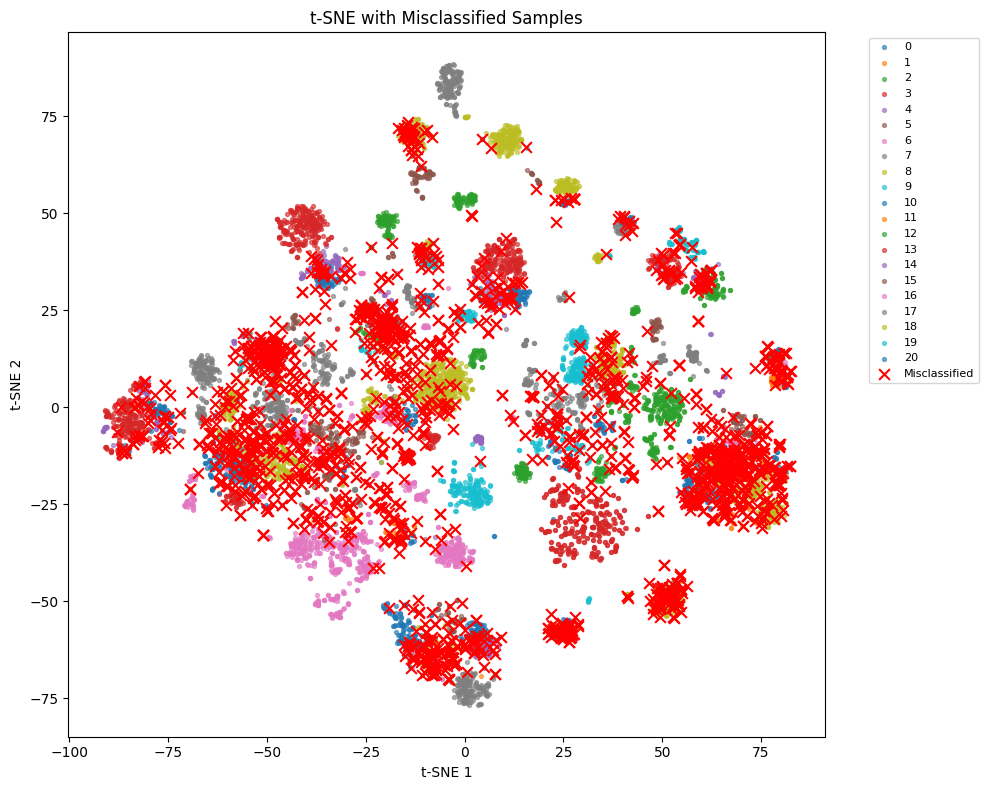

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Load data
embeddings = np.load("/content/arcface_outputs/embeddings.npy")
labels = np.load("/content/arcface_outputs/labels.npy")
preds = np.load("/content/predictions.npy")

# Identify misclassified samples
mis_idx = labels != preds

# Compute t-SNE
tsne = TSNE(n_components=2, perplexity=40, init="pca", random_state=42)
X_tsne = tsne.fit_transform(embeddings)

# Plot normal samples
plt.figure(figsize=(10,8))
num_classes = len(np.unique(labels))

for c in range(num_classes):
    idx = (labels == c) & (~mis_idx)
    plt.scatter(X_tsne[idx,0], X_tsne[idx,1],
                s=8, alpha=0.6, label=str(c))

# Plot misclassified samples
plt.scatter(X_tsne[mis_idx,0],
            X_tsne[mis_idx,1],
            c='red', s=60, marker='x', label="Misclassified")

plt.title("t-SNE with Misclassified Samples")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

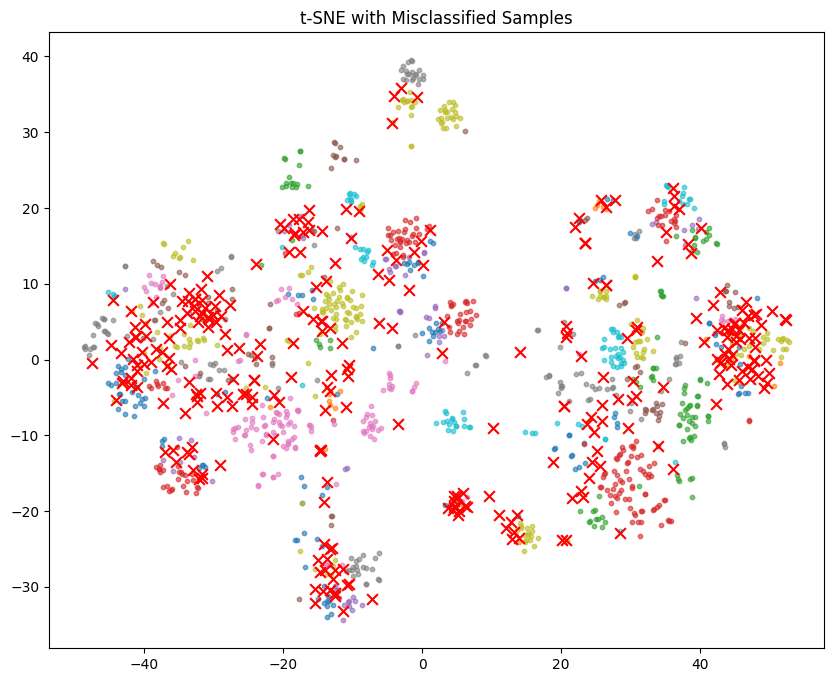

In [53]:
test_idx = test_mask.cpu().numpy()

emb_test = embeddings[test_idx]
labels_test = labels[test_idx]
preds_test = preds[test_idx]
mis_idx = labels_test != preds_test

tsne = TSNE(n_components=2, perplexity=40, random_state=42)
X_tsne = tsne.fit_transform(emb_test)

plt.figure(figsize=(10,8))

for c in np.unique(labels_test):
    idx = (labels_test == c) & (~mis_idx)
    plt.scatter(X_tsne[idx,0], X_tsne[idx,1], s=10, alpha=0.6)

plt.scatter(X_tsne[mis_idx,0],
            X_tsne[mis_idx,1],
            c='red', s=60, marker='x')

plt.title("t-SNE with Misclassified Samples")
plt.show()

In [54]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

# Load embeddings and labels
embeddings = np.load("/content/arcface_outputs/embeddings.npy")
labels = np.load("/content/arcface_outputs/labels.npy")

classes = np.unique(labels)

# Compute centroid for each cluster
centroids = []

for c in classes:
    cluster_emb = embeddings[labels == c]
    centroids.append(cluster_emb.mean(axis=0))

centroids = np.vstack(centroids)

In [55]:
similarity = cosine_similarity(centroids)

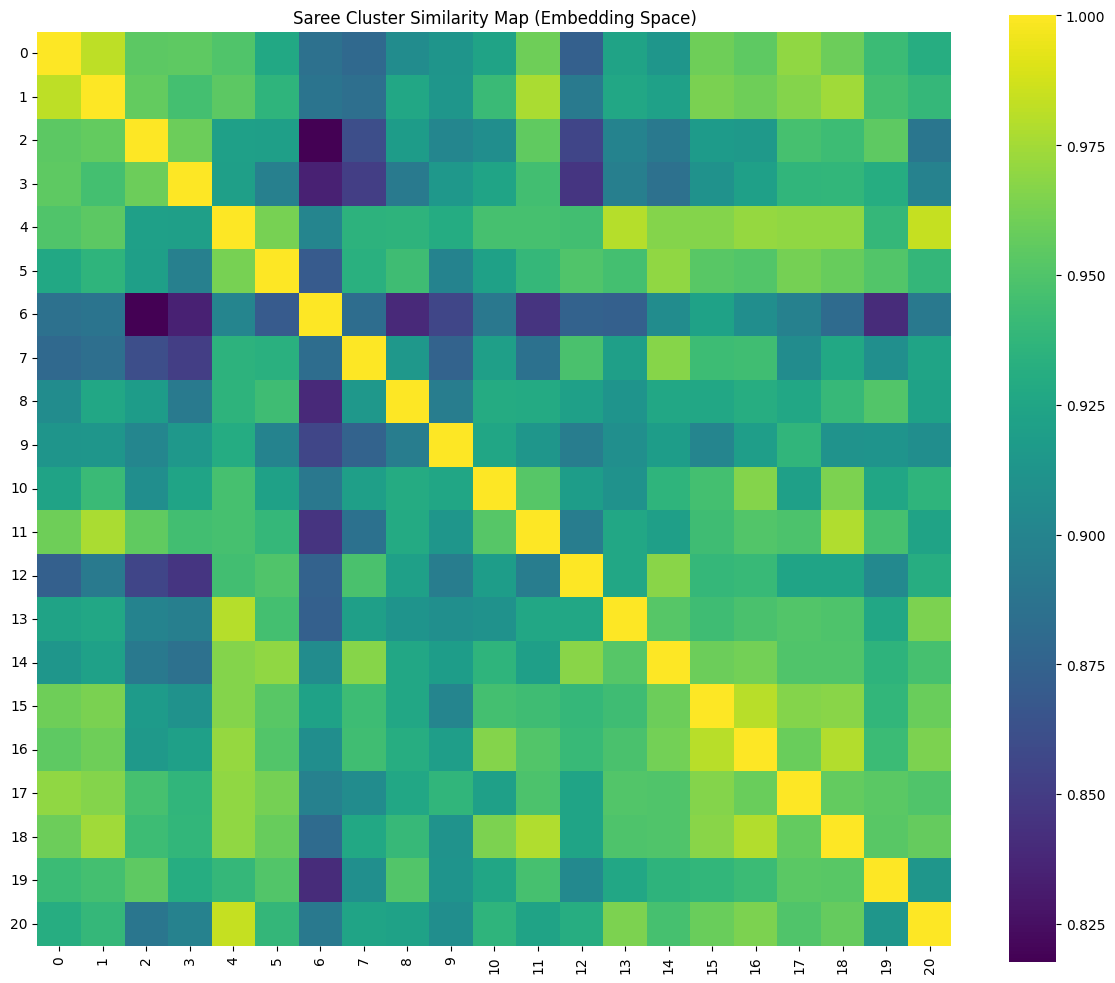

In [56]:
plt.figure(figsize=(12,10))

sns.heatmap(similarity,
            xticklabels=classes,
            yticklabels=classes,
            cmap="viridis",
            square=True)

plt.title("Saree Cluster Similarity Map (Embedding Space)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [57]:
pairs = []

for i in range(len(classes)):
    for j in range(i+1, len(classes)):
        pairs.append((classes[i], classes[j], similarity[i,j]))

pairs = sorted(pairs, key=lambda x: -x[2])

for p in pairs[:10]:
    print(p)

(np.int64(4), np.int64(20), np.float32(0.98419297))
(np.int64(0), np.int64(1), np.float32(0.98176837))
(np.int64(15), np.int64(16), np.float32(0.98007953))
(np.int64(4), np.int64(13), np.float32(0.97974527))
(np.int64(16), np.int64(18), np.float32(0.9791994))
(np.int64(11), np.int64(18), np.float32(0.9785722))
(np.int64(1), np.int64(11), np.float32(0.9766394))
(np.int64(1), np.int64(18), np.float32(0.97366554))
(np.int64(4), np.int64(16), np.float32(0.9709288))
(np.int64(0), np.int64(17), np.float32(0.9700303))


In [58]:
classes = train_ds.classes

for i, j, sim in pairs[:10]:
    print(f"{classes[i]}  <->  {classes[j]}  :  {sim:.3f}")

Gadwal  <->  Venkatgiri_Silk  :  0.984
Baluchari  <->  Banaras  :  0.982
Orissa_Ikat  <->  Paithani  :  0.980
Gadwal  <->  Mysore_Silk  :  0.980
Paithani  <->  Uppada  :  0.979
Maheshwari  <->  Uppada  :  0.979
Banaras  <->  Maheshwari  :  0.977
Banaras  <->  Uppada  :  0.974
Gadwal  <->  Paithani  :  0.971
Baluchari  <->  Pochampally_Ikat  :  0.970


In [59]:
for i, j, sim in sorted(pairs, key=lambda x: -x[2])[:15]:
    print(f"{classes[i]:20s}  <->  {classes[j]:20s}  {sim:.3f}")

Gadwal                <->  Venkatgiri_Silk       0.984
Baluchari             <->  Banaras               0.982
Orissa_Ikat           <->  Paithani              0.980
Gadwal                <->  Mysore_Silk           0.980
Paithani              <->  Uppada                0.979
Maheshwari            <->  Uppada                0.979
Banaras               <->  Maheshwari            0.977
Banaras               <->  Uppada                0.974
Gadwal                <->  Paithani              0.971
Baluchari             <->  Pochampally_Ikat      0.970
Gadwal                <->  Pochampally_Ikat      0.970
Ilkal                 <->  Narayanpet            0.970
Gadwal                <->  Uppada                0.970
Mangalgiri            <->  Narayanpet            0.968
Orissa_Ikat           <->  Uppada                0.968


In [60]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [61]:
embeddings = np.load("/content/arcface_outputs/embeddings.npy")
labels = np.load("/content/arcface_outputs/labels.npy")

classes = train_ds.classes

centroids = []

for c in range(len(classes)):
    cluster_emb = embeddings[labels == c]
    centroids.append(cluster_emb.mean(axis=0))

centroids = np.vstack(centroids)

In [62]:
similarity = cosine_similarity(centroids)

In [63]:
G = nx.Graph()

# Add nodes
for c in classes:
    G.add_node(c)

threshold = 0.97  # adjust if graph too dense

for i in range(len(classes)):
    for j in range(i+1, len(classes)):

        if similarity[i,j] > threshold:
            G.add_edge(classes[i], classes[j], weight=similarity[i,j])

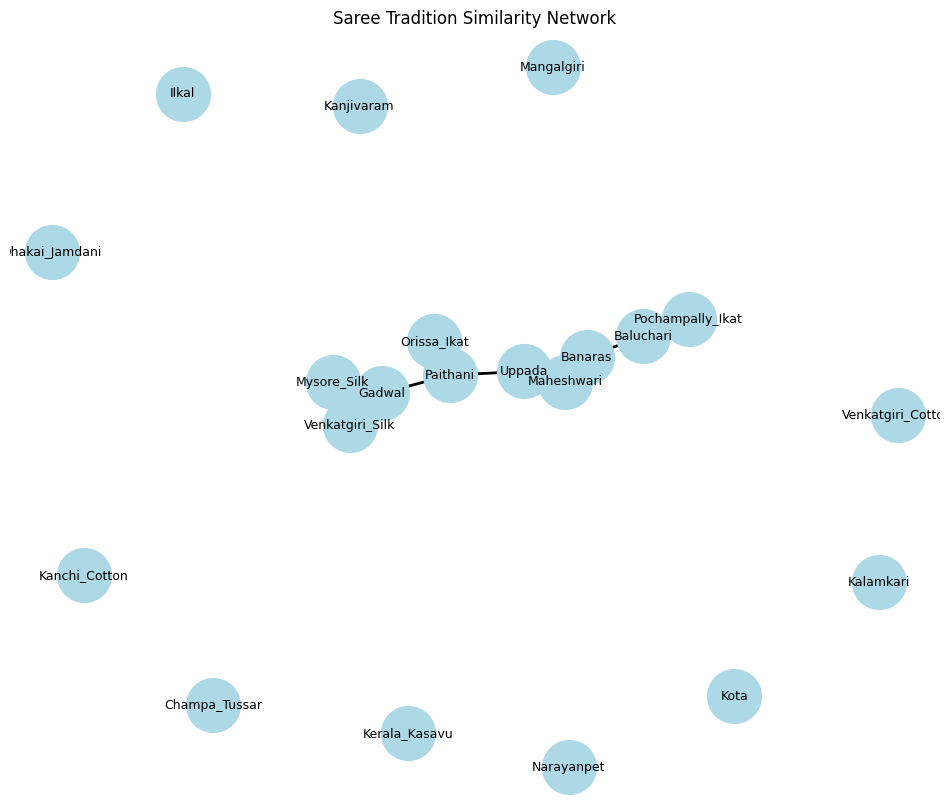

In [64]:
plt.figure(figsize=(12,10))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, pos,
                       node_size=1500,
                       node_color="lightblue")

nx.draw_networkx_edges(G, pos,
                       width=2)

nx.draw_networkx_labels(G, pos,
                        font_size=9)

plt.title("Saree Tradition Similarity Network")
plt.axis("off")
plt.show()

In [65]:
image_paths = []

image_paths.extend([s[0] for s in train_ds.samples])
image_paths.extend([s[0] for s in val_ds.samples])
image_paths.extend([s[0] for s in test_ds.samples])

image_paths = np.array(image_paths)

np.save("/content/image_paths.npy", image_paths)

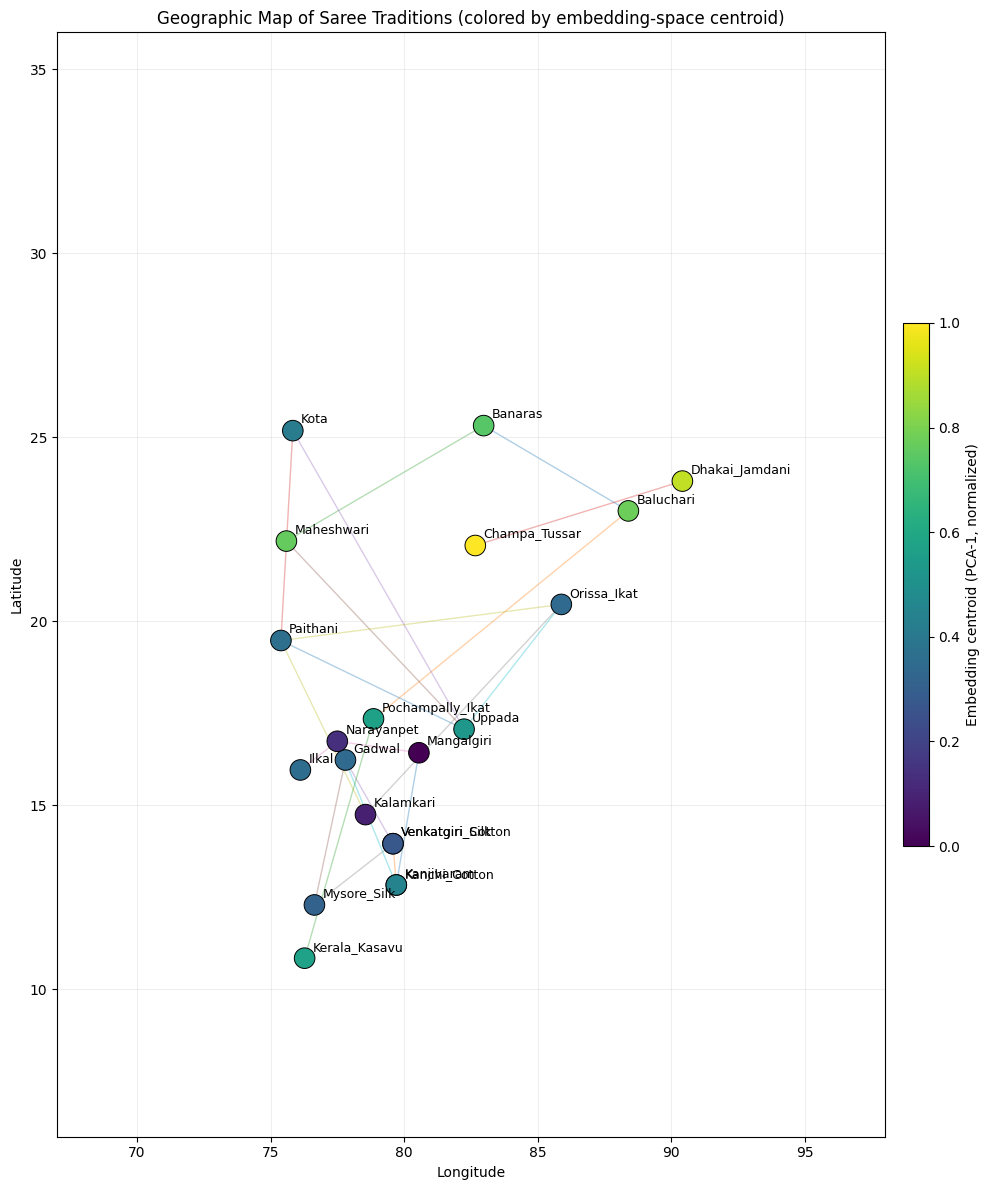

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# ---------- Load your data ----------
embeddings = np.load("/content/arcface_outputs/embeddings.npy")
labels     = np.load("/content/labels.npy")

# IMPORTANT: Use YOUR class names in the correct index order
# If you trained with ImageFolder, this is usually:
# classes = train_ds.classes
classes = [
 'Baluchari','Banaras','Champa_Tussar','Dhakai_Jamdani','Gadwal','Ilkal','Kalamkari',
 'Kanchi_Cotton','Kanjivaram','Kerala_Kasavu','Kota','Maheshwari','Mangalgiri',
 'Mysore_Silk','Narayanpet','Orissa_Ikat','Paithani','Pochampally_Ikat','Uppada',
 'Venkatgiri_Cotton','Venkatgiri_Silk'
]

# ---------- 1) Cluster centroids in embedding space ----------
C = len(classes)
centroids = np.vstack([embeddings[labels == c].mean(axis=0) for c in range(C)])

# ---------- 2) Convert centroids -> 1D "embedding signature" for coloring ----------
# (PCA-1 is a simple, stable choice for a single color scale)
pca = PCA(n_components=1, random_state=42)
color_val = pca.fit_transform(centroids).squeeze()
color_val = (color_val - color_val.min()) / (color_val.max() - color_val.min() + 1e-9)

# ---------- 3) Similarity edges between clusters (optional) ----------
sim = cosine_similarity(centroids)
np.fill_diagonal(sim, -1.0)

# For each node, connect to top-k most similar clusters
top_k = 2
edges = []
for i in range(C):
    nn = np.argsort(sim[i])[::-1][:top_k]
    for j in nn:
        if i < j:
            edges.append((i, j, sim[i, j]))

# ---------- 4) Geographic coordinates (EDIT/VERIFY these) ----------
# Use one representative origin point per tradition.
# lat, lon
origin_latlon = {
 'Baluchari': (23.000, 88.390),          # West Bengal (Bishnupur/Baluchar region)
 'Banaras': (25.317, 82.973),            # Varanasi
 'Champa_Tussar': (22.060, 82.660),      # Champa, Chhattisgarh (approx)
 'Dhakai_Jamdani': (23.810, 90.412),     # Dhaka (outside India; still show)
 'Gadwal': (16.233, 77.800),             # Gadwal, Telangana
 'Ilkal': (15.963, 76.113),              # Ilkal, Karnataka
 'Kalamkari': (14.750, 78.550),          # Andhra region (approx; Srikalahasti/Machilipatnam differ)
 'Kanchi_Cotton': (12.838, 79.703),      # Kanchipuram
 'Kanjivaram': (12.838, 79.703),         # Kanchipuram (same place)
 'Kerala_Kasavu': (10.850, 76.272),      # Kerala (state centroid)
 'Kota': (25.180, 75.830),               # Kota, Rajasthan
 'Maheshwari': (22.180, 75.590),         # Maheshwar, MP
 'Mangalgiri': (16.430, 80.550),         # Mangalagiri, AP
 'Mysore_Silk': (12.296, 76.639),        # Mysuru
 'Narayanpet': (16.742, 77.495),         # Narayanpet, Telangana
 'Orissa_Ikat': (20.460, 85.880),        # Odisha (Bhubaneswar approx)
 'Paithani': (19.479, 75.385),           # Paithan, Maharashtra
 'Pochampally_Ikat': (17.350, 78.850),   # Bhoodan Pochampally (approx)
 'Uppada': (17.070, 82.240),             # Uppada, AP
 'Venkatgiri_Cotton': (13.960, 79.580),  # Venkatagiri, AP
 'Venkatgiri_Silk': (13.960, 79.580),    # Venkatagiri, AP
}

# ---------- 5) Plot (simple "India-ish" lon/lat frame) ----------
plt.figure(figsize=(10, 12))
ax = plt.gca()

# Rough map frame (keeps it dependency-free). You can replace with GeoPandas outline later.
ax.set_xlim(67, 98)     # lon
ax.set_ylim(6, 36)      # lat
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Geographic Map of Saree Traditions (colored by embedding-space centroid)")

# Draw similarity edges (optional)
for i, j, w in edges:
    ci, cj = classes[i], classes[j]
    if ci not in origin_latlon or cj not in origin_latlon:
        continue
    lat1, lon1 = origin_latlon[ci]
    lat2, lon2 = origin_latlon[cj]
    ax.plot([lon1, lon2], [lat1, lat2], linewidth=1, alpha=0.35)

# Draw nodes
lats, lons, cols = [], [], []
for i, name in enumerate(classes):
    if name not in origin_latlon:
        continue
    lat, lon = origin_latlon[name]
    lats.append(lat); lons.append(lon); cols.append(color_val[i])

sc = ax.scatter(lons, lats, c=cols, s=220, cmap="viridis", edgecolor="k", linewidth=0.7, zorder=3)
plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label="Embedding centroid (PCA-1, normalized)")

# Labels
for i, name in enumerate(classes):
    if name not in origin_latlon:
        continue
    lat, lon = origin_latlon[name]
    ax.text(lon + 0.3, lat + 0.2, name, fontsize=9)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

/tmp/ipykernel_242/1179877560.py:25: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist_matrix, method="ward")


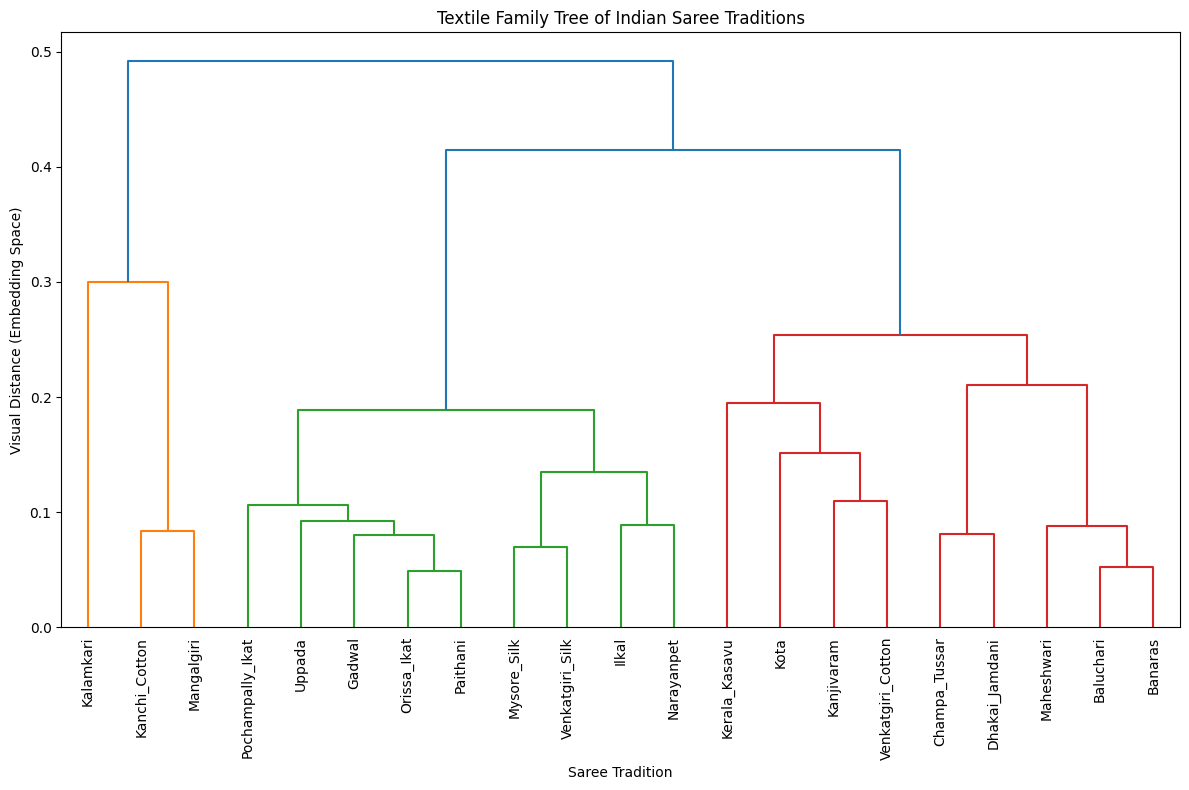

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics.pairwise import cosine_distances

# Load embeddings and labels
embeddings = np.load("/content/arcface_outputs/embeddings.npy")
labels = np.load("/content/labels.npy")

# Class names
classes = train_ds.classes

# Compute centroid for each cluster
centroids = []
for c in range(len(classes)):
    cluster_emb = embeddings[labels == c]
    centroids.append(cluster_emb.mean(axis=0))

centroids = np.vstack(centroids)

# Compute cosine distance between clusters
dist_matrix = cosine_distances(centroids)

# Hierarchical clustering
Z = linkage(dist_matrix, method="ward")

# Plot dendrogram
plt.figure(figsize=(12,8))

dendrogram(
    Z,
    labels=classes,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title("Textile Family Tree of Indian Saree Traditions")
plt.ylabel("Visual Distance (Embedding Space)")
plt.xlabel("Saree Tradition")
plt.tight_layout()
plt.show()

In [70]:
!ls /content

arcface_outputs		  data_saree2_master_clean  image_paths.npy
best_arcface.pth	  data_saree2_stratified    labels.npy
data_saree2_cross_domain  Dataset		    predictions.npy
data_saree2_layout10	  drive			    sample_data


In [82]:
!cp -r /content/arcface_outputs \
/content/image_paths.npy \
/content/labels.npy \
/content/predictions.npy \
/content/best_arcface.pth \
/content/drive/MyDrive/phd_v1.0/




In [83]:
!ls /content/drive/MyDrive/phd_v1.0

arcface_outputs  best_arcface.pth  image_paths.npy  labels.npy	predictions.npy
